In [2]:
pip install tensorflow matplotlib pandas numpy scikit-learn seaborn pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install matplotlib pandas numpy scikit-learn seaborn pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import classification_report, confusion_matrix

In [10]:
DATASET_PATH = r"D:\Git Hub IMP\car_type_classification"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [13]:
classes = sorted(os.listdir(DATASET_PATH))

print("Classes found:")
for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

Classes found:
Hatchback : 602 images
Other : 600 images
Pickup : 693 images
SUV : 680 images
Sedan : 616 images


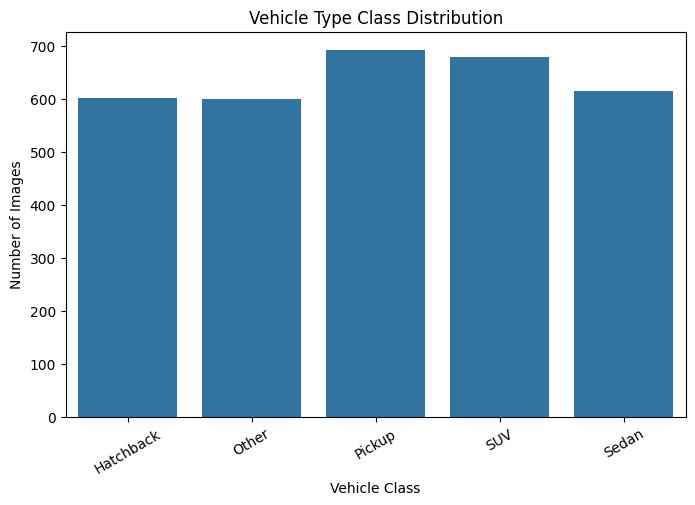

,Class,Image Count
0,Hatchback,602
1,Other,600
2,Pickup,693
3,SUV,680
4,Sedan,616


In [14]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(class_path):
        class_counts[cls] = len(os.listdir(class_path))

df_counts = pd.DataFrame({
    "Class": class_counts.keys(),
    "Image Count": class_counts.values()
})

plt.figure(figsize=(8,5))
sns.barplot(data=df_counts, x="Class", y="Image Count")
plt.title("Vehicle Type Class Distribution")
plt.xlabel("Vehicle Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.show()

df_counts

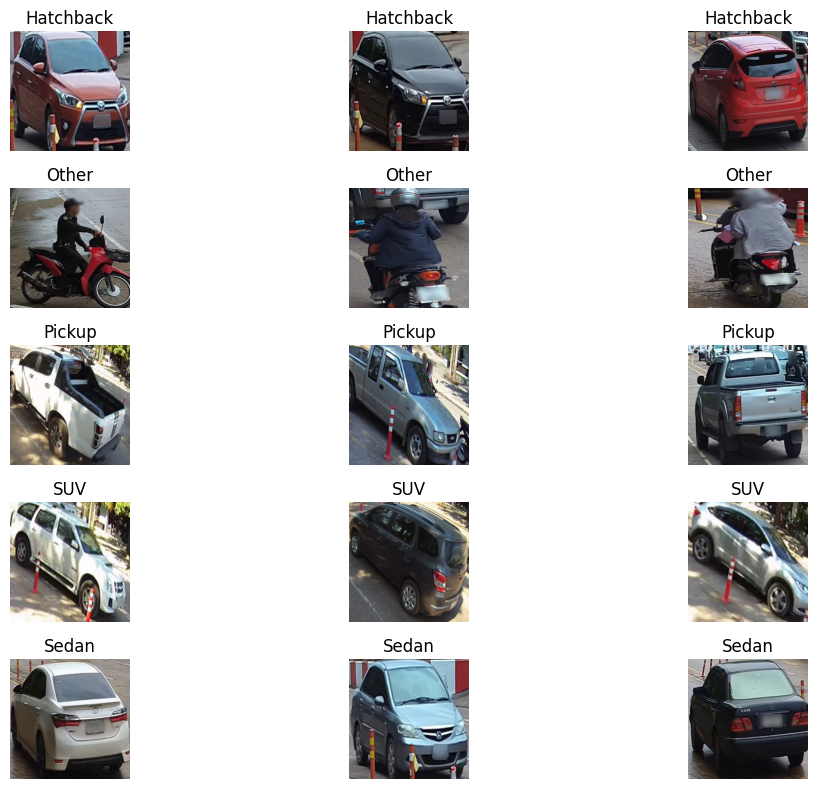

In [18]:
from PIL import Image

plt.figure(figsize=(12, 8))

image_index = 1

for cls in classes:

    class_path = os.path.join(DATASET_PATH, cls)

    if os.path.isdir(class_path):

        images = os.listdir(class_path)[:3]

        for img_name in images:

            img_path = os.path.join(class_path, img_name)

            img = Image.open(img_path)
            img = img.resize(IMG_SIZE)

            plt.subplot(len(classes), 3, image_index)
            plt.imshow(img)
            plt.title(cls)
            plt.axis("off")

            image_index += 1

plt.tight_layout()
plt.show()

In [19]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [20]:
full_dataset = datasets.ImageFolder(
    root=DATASET_PATH,
    transform=train_transform
)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

torch.manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size]
)

val_dataset.dataset.transform = val_transform

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Class names: ['Hatchback', 'Other', 'Pickup', 'SUV', 'Sedan']
Number of classes: 5
Total images: 3191
Training images: 2552
Validation images: 639


In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [23]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_features, num_classes)
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\knowl/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:32<00:00, 1.44MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [25]:
EPOCHS = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train

    model.eval()

    val_running_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/10] Train Loss: 0.3635 Train Acc: 0.8793 Val Loss: 0.0392 Val Acc: 0.9922
Epoch [2/10] Train Loss: 0.0189 Train Acc: 0.9988 Val Loss: 0.0140 Val Acc: 0.9969
Epoch [3/10] Train Loss: 0.0063 Train Acc: 0.9996 Val Loss: 0.0093 Val Acc: 0.9984
Epoch [4/10] Train Loss: 0.0030 Train Acc: 1.0000 Val Loss: 0.0080 Val Acc: 0.9984
Epoch [5/10] Train Loss: 0.0024 Train Acc: 0.9996 Val Loss: 0.0067 Val Acc: 1.0000
Epoch [6/10] Train Loss: 0.0025 Train Acc: 1.0000 Val Loss: 0.0073 Val Acc: 0.9984
Epoch [7/10] Train Loss: 0.0013 Train Acc: 1.0000 Val Loss: 0.0076 Val Acc: 0.9984
Epoch [8/10] Train Loss: 0.0010 Train Acc: 1.0000 Val Loss: 0.0059 Val Acc: 0.9984
Epoch [9/10] Train Loss: 0.0010 Train Acc: 1.0000 Val Loss: 0.0047 Val Acc: 1.0000
Epoch [10/10] Train Loss: 0.0008 Train Acc: 1.0000 Val Loss: 0.0042 Val Acc: 1.0000


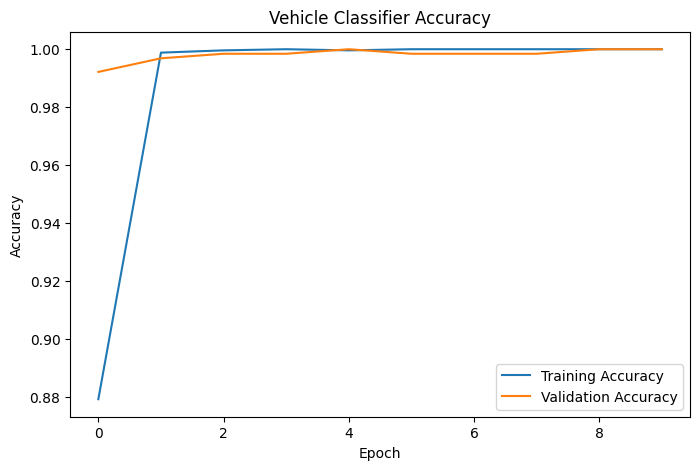

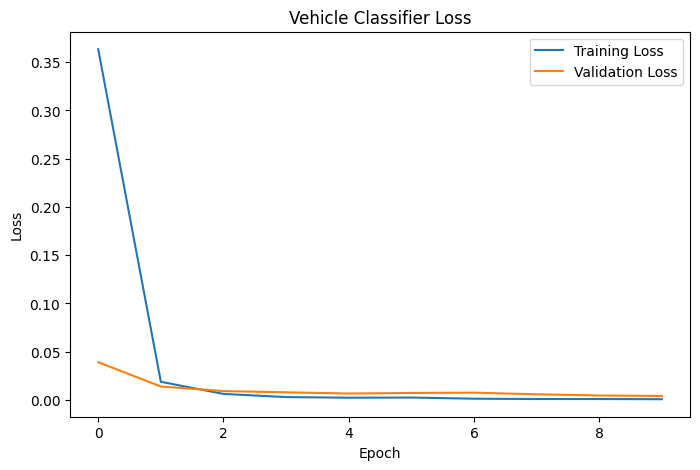

In [26]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.title("Vehicle Classifier Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Vehicle Classifier Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

              precision    recall  f1-score   support

   Hatchback       1.00      1.00      1.00       112
       Other       1.00      1.00      1.00       122
      Pickup       1.00      1.00      1.00       159
         SUV       1.00      1.00      1.00       121
       Sedan       1.00      1.00      1.00       125

    accuracy                           1.00       639
   macro avg       1.00      1.00      1.00       639
weighted avg       1.00      1.00      1.00       639



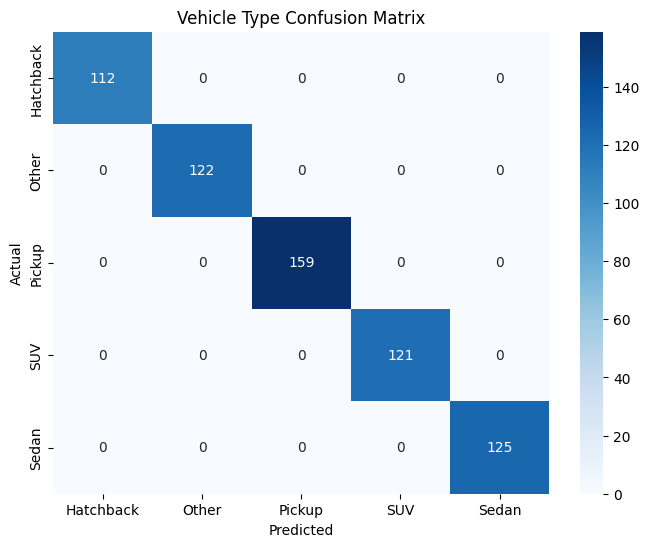

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.title("Vehicle Type Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
import json

torch.save(model.state_dict(), "vehicle_type_resnet18.pth")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model saved as vehicle_type_resnet18.pth")
print("Labels saved as class_names.json")

Model saved as vehicle_type_resnet18.pth
Labels saved as class_names.json


In [29]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
d:\Microsoft VS Code


In [30]:
import os

print(os.path.abspath("vehicle_type_resnet18.pth"))
print(os.path.exists("vehicle_type_resnet18.pth"))

d:\Microsoft VS Code\vehicle_type_resnet18.pth
True
